In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
!pip install evaluate
!pip install datasets
!pip install transformers -U
!pip install accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.4/10.4 MB 116.8 MB/s eta 0:00:00
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


In [4]:
import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer, EarlyStoppingCallback
import evaluate

In [8]:
import pandas as pd
import re

main_data = pd.read_csv('/content/drive/MyDrive/Color_Doppler_Echo_Data/Final_data.csv')
print(main_data.head())

                                      Medical_Report           Cardiac_Class  \
0  Age: 55, Sex: Male, IVST: nan, LVIDd: 56 mm, L...   Myocardial_Infarction   
1  Age: 55, Sex: Male, IVST: nan, LVIDd: 51 mm, L...  Ischemic_Heart_Disease   
2  Age: 55, Sex: Female, IVST: nan, LVIDd: 58 mm,...  Ischemic_Heart_Disease   
3  Age: 33, Sex: Female, IVST: nan, LVIDd: 53 mm,...                  Normal   
4  Age: 45, Sex: Female, IVST: nan, LVIDd: 53 mm,...  Ischemic_Heart_Disease   

      label  
0  Moderate  
1  Moderate  
2  Moderate  
3    Normal  
4      Mild  


In [9]:
def preprocess_patient_data(data):
    data = data.strip()
    data = re.sub(r'\s+', ' ', data)
    data = re.sub(r'[-:;]', '', data)
    return data

data_list = []
for idx, entry in enumerate(main_data.to_dict('records')):
  cleaned_patient_data = preprocess_patient_data(entry['Medical_Report'])
  data_list.append({
      'id': idx + 1,
      'label': entry['label'],
      'Medical_Report': cleaned_patient_data
  })

main_data = pd.DataFrame(data_list)
print(main_data)

      id     label                                     Medical_Report
0      1  Moderate  Age 55, Sex Male, IVST nan, LVIDd 56 mm, LA 39...
1      2  Moderate  Age 55, Sex Male, IVST nan, LVIDd 51 mm, LA 24...
2      3  Moderate  Age 55, Sex Female, IVST nan, LVIDd 58 mm, LA ...
3      4    Normal  Age 33, Sex Female, IVST nan, LVIDd 53 mm, LA ...
4      5      Mild  Age 45, Sex Female, IVST nan, LVIDd 53 mm, LA ...
..   ...       ...                                                ...
713  714    Normal  Age 44, Sex Male, IVST 10 mm, LVIDd 37 mm, LA ...
714  715      Mild  Age 58, Sex Male, IVST 23 mm, LVIDd 45 mm, LA ...
715  716      Mild  Age 30, Sex Male, IVST 9 mm, LVIDd 55 mm, LA 4...
716  717      Mild  Age 63, Sex Female, IVST 9 mm, LVIDd 39 mm, LA...
717  718      Mild  Age 30, Sex Male, IVST 8 mm, LVIDd 45 mm, LA 3...

[718 rows x 3 columns]


In [10]:
percent = (main_data.isnull().sum() / main_data.shape[0]) * 100
new_train = pd.DataFrame(data=percent, columns=['Percentofnullvalues'])
new_train = new_train.sort_values(by='Percentofnullvalues', ascending=False)
print(new_train.head(15))

                Percentofnullvalues
id                              0.0
label                           0.0
Medical_Report                  0.0


In [11]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              718 non-null    int64 
 1   label           718 non-null    object
 2   Medical_Report  718 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.0+ KB


In [12]:
def remove_columns(data):
    ''' Computing percent of null values in a dataset based on the feature and removing those features having 70 or more than 70 percent of null values '''
    columns_to_be_removed = []
    percent = (data.isnull().sum()/data.shape[0]) * 100
    for col in data.columns:
        if percent.loc[col] >= 80:
            columns_to_be_removed.append(col)
    new_data = data.drop(columns=columns_to_be_removed)
    return new_data
main_data = remove_columns(main_data)


In [13]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              718 non-null    int64 
 1   label           718 non-null    object
 2   Medical_Report  718 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.0+ KB


In [14]:
main_data = main_data.dropna()
main_data.head(10)

,id,label,Medical_Report
0,1,Moderate,"Age 55, Sex Male, IVST nan, LVIDd 56 mm, LA 39..."
1,2,Moderate,"Age 55, Sex Male, IVST nan, LVIDd 51 mm, LA 24..."
2,3,Moderate,"Age 55, Sex Female, IVST nan, LVIDd 58 mm, LA ..."
3,4,Normal,"Age 33, Sex Female, IVST nan, LVIDd 53 mm, LA ..."
4,5,Mild,"Age 45, Sex Female, IVST nan, LVIDd 53 mm, LA ..."
5,6,Normal,"Age 71, Sex Female, IVST nan, LVIDd 47 mm, LA ..."
6,7,Moderate,"Age 45, Sex Male, IVST nan, LVIDd 61 mm, LA 38..."
7,8,Mild,"Age 52, Sex Female, IVST nan, LVIDd 40 mm, LA ..."
8,9,Normal,"Age 08, Sex Female, IVST nan, LVIDd 37 mm, LA ..."
9,10,Normal,"Age 20, Sex Female, IVST nan, LVIDd 39 mm, LA ..."


In [15]:
main_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 718 entries, 0 to 717
Data columns (total 3 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   id              718 non-null    int64 
 1   label           718 non-null    object
 2   Medical_Report  718 non-null    object
dtypes: int64(1), object(2)
memory usage: 17.0+ KB


In [16]:
print("\nSummary Statistics:")
print(main_data.describe())


Summary Statistics:
               id
count  718.000000
mean   359.500000
std    207.413034
min      1.000000
25%    180.250000
50%    359.500000
75%    538.750000
max    718.000000


In [17]:
def encoder(data):
    values_list = list(data.unique())
    temp_dict = {}
    for item in values_list:
        index = values_list.index(item)
        temp_dict.update({item:index})
    print(temp_dict)
    for d in data.index:
        data[d] = temp_dict[data[d]]
    return data, temp_dict

print(main_data['label'].value_counts())
classes = main_data["label"].unique()

main_data['label'], label_map = encoder(main_data['label'])

label
Mild        269
Moderate    205
Normal      165
Severe       79
Name: count, dtype: int64
{'Moderate': 0, 'Normal': 1, 'Mild': 2, 'Severe': 3}


/tmp/ipython-input-652/1146516202.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[d] = temp_dict[data[d]]
/tmp/ipython-input-652/1146516202.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[d] = temp_dict[data[d]]
/tmp/ipython-input-652/1146516202.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data[d] = temp_dict[data[d]]
/tmp/ipython-input-652/1146516202.py:9: SettingWithCopyWarning: 
A value is trying to be set o

In [18]:
import pandas as pd
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, TrainingArguments, Trainer
import torch
import numpy as np
import evaluate
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [21]:
# Encode labels as integers
label_map = {label: idx for idx, label in enumerate(main_data['label'].unique())}
main_data['label'] = main_data['label'].map(label_map)

# Verify the label encoding
print(main_data['label'].value_counts())
print(label_map)


label
2    269
0    205
1    165
3     79
Name: count, dtype: int64
{0: 0, 1: 1, 2: 2, 3: 3}


In [30]:
label_to_id_mapping = {label: idx for idx, label in enumerate(classes)}
print(label_to_id_mapping)

{'Moderate': 0, 'Normal': 1, 'Mild': 2, 'Severe': 3}


In [31]:
from sklearn.metrics import classification_report

# Create a reverse map from id to label name for target_names
id_to_label_name = {v: k for k, v in label_to_id_mapping.items()}
target_names = [id_to_label_name[i] for i in sorted(id_to_label_name.keys())]

# Generate and print the classification report
report = classification_report(y_test_actual_labels, y_test_pred_labels, target_names=target_names)
print(report)

              precision    recall  f1-score   support

    Moderate       0.85      0.87      0.86        38
      Normal       0.97      1.00      0.99        34
        Mild       0.92      0.92      0.92        59
      Severe       1.00      0.85      0.92        13

    accuracy                           0.92       144
   macro avg       0.93      0.91      0.92       144
weighted avg       0.92      0.92      0.92       144



In [24]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets randomly
# test_size=0.2 means 20% of the data goes to the test set
train_data, test_data = train_test_split(main_data, test_size=0.2, random_state=42, shuffle=True)

# Convert to Hugging Face Datasets
hg_train_data = Dataset.from_pandas(train_data)
hg_test_data = Dataset.from_pandas(test_data)

print(f'The length of train_data is {len(hg_train_data)}')
print(f'The length of test_data is {len(hg_test_data)}')

The length of train_data is 574
The length of test_data is 144


In [25]:
print("Training Set Label Distribution:")
print(train_data['label'].value_counts())
print("\nTesting Set Label Distribution:")
print(test_data['label'].value_counts())

Training Set Label Distribution:
label
2    210
0    167
1    131
3     66
Name: count, dtype: int64

Testing Set Label Distribution:
label
2    59
0    38
1    34
3    13
Name: count, dtype: int64


In [26]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
tokenizer = AutoTokenizer.from_pretrained("alvaroalon2/biobert_diseases_ner")

# Function to tokenize data
def tokenize_dataset(data):
    return tokenizer(data["Medical_Report"], truncation=True, padding="max_length")

dataset_train = hg_train_data.map(tokenize_dataset, batched=True)
dataset_test = hg_test_data.map(tokenize_dataset, batched=True)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/746 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/574 [00:00<?, ? examples/s]

Map:   0%|          | 0/144 [00:00<?, ? examples/s]

In [27]:
# Load model
model = AutoModelForSequenceClassification.from_pretrained(
    "alvaroalon2/biobert_diseases_ner",
    num_labels=len(label_map),
    ignore_mismatched_sizes=True
).to(device=device)

# Set up training arguments
training_args = TrainingArguments(
    output_dir="/content/disease_classification/model_output/",
    logging_dir='/content/disease_classification/logs',

    # Strategies
    logging_strategy='epoch',
    eval_strategy='epoch',
    save_strategy='epoch',

    # Best Model Handling
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",

    # Hyperparameters
    num_train_epochs=30,
    per_device_train_batch_size=35,
    per_device_eval_batch_size=20,
    learning_rate=5e-6,
    seed=42,
)

pytorch_model.bin:   0%|          | 0.00/431M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: alvaroalon2/biobert_diseases_ner
Key                          | Status     |                                                                                       
-----------------------------+------------+---------------------------------------------------------------------------------------
bert.embeddings.position_ids | UNEXPECTED |                                                                                       
bert.pooler.dense.bias       | MISSING    |                                                                                       
bert.pooler.dense.weight     | MISSING    |                                                                                       
classifier.weight            | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3, 768]) vs model:torch.Size([4, 768])
classifier.bias              | MISMATCH   | Reinit due to size mismatch - ckpt: torch.Size([3]) vs model:torch.Size([4])          

N

In [28]:
from transformers import EarlyStoppingCallback

# Load the metric outside the function to avoid reloading it every step
metric = evaluate.load("accuracy")

# Function to compute metrics
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=1)
    return metric.compute(predictions=predictions, references=labels)

# Train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_test,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=5)] # Stop if accuracy doesn't improve for 3 epochs
)

# Train the model
trainer.train()

# Evaluate the model (This will evaluate the BEST model found, not just the last one)
trainer.evaluate(dataset_test)

Epoch,Training Loss,Validation Loss,Accuracy
1,1.346672,1.219163,0.409722
2,1.219889,1.056691,0.597222
3,1.079466,0.894222,0.756944
4,0.940732,0.764465,0.770833
5,0.837496,0.678483,0.777778
6,0.772179,0.626687,0.763889
7,0.716551,0.565693,0.777778
8,0.679734,0.521573,0.833333
9,0.636428,0.494275,0.833333
10,0.602012,0.452228,0.840278


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

{'eval_loss': 0.2653951048851013,
 'eval_accuracy': 0.9166666666666666,
 'eval_runtime': 0.9772,
 'eval_samples_per_second': 147.361,
 'eval_steps_per_second': 8.187,
 'epoch': 24.0}


        Recall Score ----> 0.9166666666666666
        F1 Score --------> 0.9166666666666666



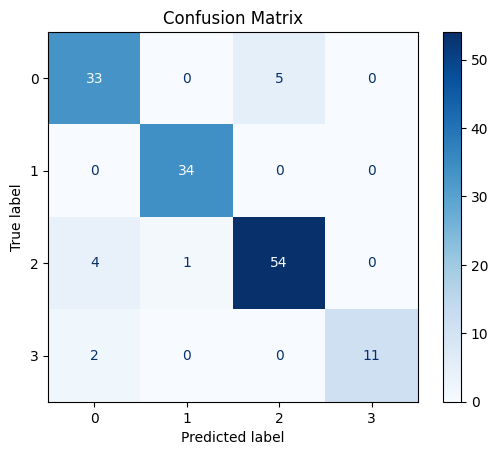

In [33]:
from scipy.special import softmax
y_test_predict = trainer.predict(dataset_test)
y_test_logits = y_test_predict.predictions
y_test_probabilities = softmax(y_test_logits, axis=1)
y_test_pred_labels = np.argmax(y_test_probabilities, axis=1)
y_test_actual_labels = y_test_predict.label_ids

metric_f1 = evaluate.load("f1")
f1_score = metric_f1.compute(predictions=y_test_pred_labels, references=y_test_actual_labels, average='micro')

metric_recall = evaluate.load("recall")
recall_score = metric_recall.compute(predictions=y_test_pred_labels, references=y_test_actual_labels, average='micro')

print(f"""
        Recall Score ----> {list(recall_score.values())[0]}
        F1 Score --------> {list(f1_score.values())[0]}
""")

# Plot confusion matrix
cm = confusion_matrix(y_test_actual_labels, y_test_pred_labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(label_map.keys()))
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()


In [34]:
from sklearn.metrics import classification_report

# Create a reverse map from id to label name for target_names
id_to_label_name = {v: k for k, v in label_to_id_mapping.items()}
target_names = [id_to_label_name[i] for i in sorted(id_to_label_name.keys())]

# Generate and print the classification report
report = classification_report(y_test_actual_labels, y_test_pred_labels, target_names=target_names)
print(report)

              precision    recall  f1-score   support

    Moderate       0.85      0.87      0.86        38
      Normal       0.97      1.00      0.99        34
        Mild       0.92      0.92      0.92        59
      Severe       1.00      0.85      0.92        13

    accuracy                           0.92       144
   macro avg       0.93      0.91      0.92       144
weighted avg       0.92      0.92      0.92       144



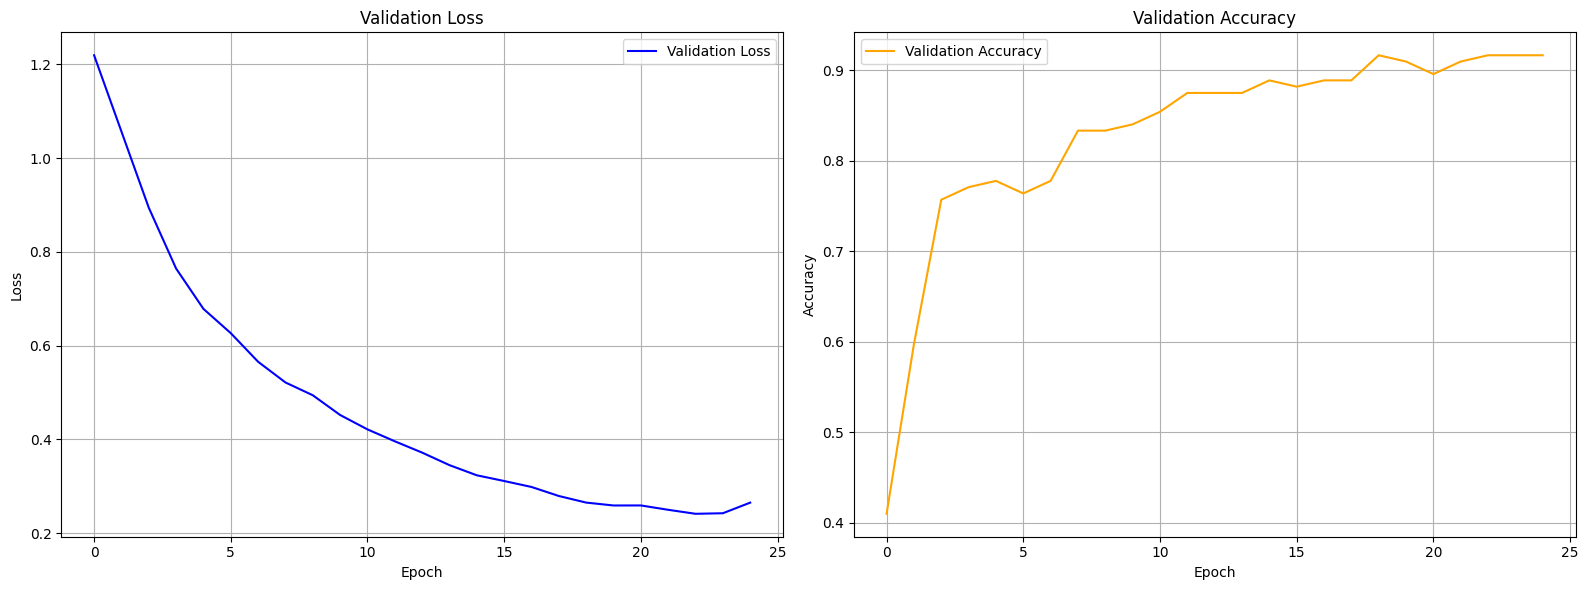

In [35]:
import matplotlib.pyplot as plt

# Extract validation metrics from trainer state
val_loss = [metrics.get('eval_loss') for metrics in trainer.state.log_history if 'eval_loss' in metrics]
val_acc = [metrics.get('eval_accuracy') for metrics in trainer.state.log_history if 'eval_accuracy' in metrics]

# Plot validation metrics
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot validation loss
ax1.plot(range(len(val_loss)), val_loss, label='Validation Loss', color='blue')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Validation Loss')
ax1.legend()
ax1.grid(True)

# Plot validation accuracy
ax2.plot(range(len(val_acc)), val_acc, label='Validation Accuracy', color='orange')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Validation Accuracy')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()


In [36]:
folder_name = "/content/drive/MyDrive/disease_classification/analysis_u"
tokenizer.save_pretrained(folder_name + '/')
trainer.save_model(folder_name + '/')


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [37]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification
import torch

# Load tokenizer and model
folder_name = "/content/drive/MyDrive/disease_classification/analysis_u"
tokenizer = AutoTokenizer.from_pretrained(folder_name)
model = AutoModelForSequenceClassification.from_pretrained(folder_name)

# Input text for prediction
input_text = "Age : 70years; descriptions : - lv a cavity size - normal, - wall thickness - normal, - wall motion - normal, others - not mentioned in the text. ; color_flow_report : mitral valve - normal aortic valve - normal pulmonary valve - normal tricuspid valve - normal impression "

# Tokenize input text
inputs = tokenizer(input_text, return_tensors="pt", truncation=True, padding=True, max_length=512)

# Make predictions
with torch.no_grad():
    outputs = model(**inputs)
    predicted_class = torch.argmax(outputs.logits, dim=1).item()

# Map predicted class index to label
label_map = {'Moderate': 0, 'Normal': 1, 'Mild': 2, 'Severe': 3}
# Create a reverse map: ID -> Label
id2label = {v: k for k, v in label_map.items()}

predicted_label = id2label[predicted_class]

# Print predicted label
print(f"The predicted label of the text is: {predicted_label}")

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

The predicted label of the text is: Normal


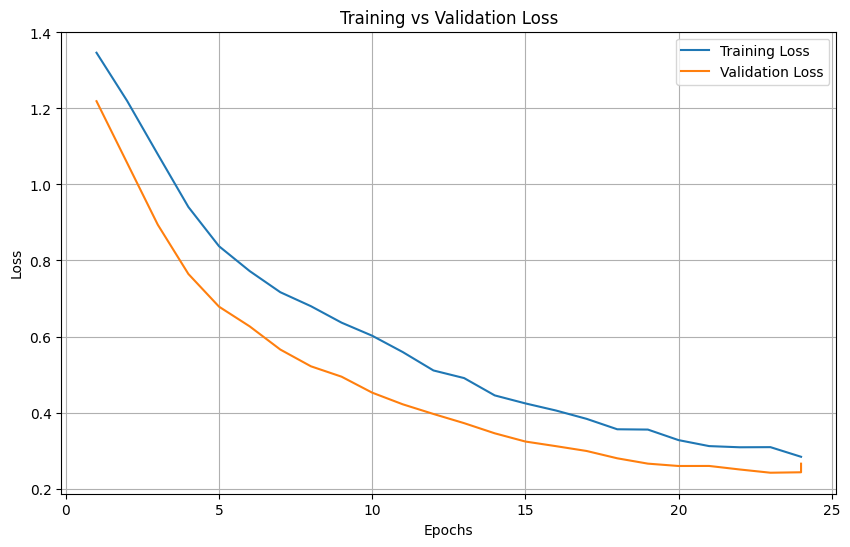

In [38]:
import matplotlib.pyplot as plt
import pandas as pd

# Extract history
history = trainer.state.log_history

# Extract training loss (recorded every logging_steps)
train_loss = [{'epoch': x['epoch'], 'loss': x['loss']} for x in history if 'loss' in x]

# Extract validation loss (recorded every eval_steps)
eval_loss = [{'epoch': x['epoch'], 'eval_loss': x['eval_loss']} for x in history if 'eval_loss' in x]

# Convert to DataFrames
df_train = pd.DataFrame(train_loss)
df_eval = pd.DataFrame(eval_loss)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(df_train['epoch'], df_train['loss'], label='Training Loss')
plt.plot(df_eval['epoch'], df_eval['eval_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.legend()
plt.grid(True)
plt.show()